# Q8 — A Hierarchical Bayesian Observer with Uncertain Prior Context

**Question (template Q8):** Simulate a Hierarchical Bayesian observer (Lee & Mumford, 2003, *JOSA A* — [pdf](https://www.cnbc.cmu.edu/~tai/papers/lee_mumford_josa.pdf)) that "believes" that in some trials the prior is uniform, and in others it is circular (Von Mises). **Can this model reproduce the observed bimodality of subject estimate distributions?**

We use the "four priors" motion-direction estimation dataset from [Laquitaine & Gardner, *Neuron* 2018](https://doi.org/10.1016/j.neuron.2017.12.011) ([source repo](https://github.com/steevelaquitaine/projInference/tree/gh-pages/notebooks)): 12 subjects estimated motion direction under 4 block-wise circular priors (std 10/40/60/80°, mean 225°) and 3 coherence levels. Laquitaine & Gardner found that despite good mean/variance fits from a standard Bayesian observer, subject estimate distributions were **bimodal**, and explained this with a **switching observer** that reports either the prior or the evidence, never a blend.

**Hypothesis:** a higher-level context node infers *which* generative model (uninformative uniform vs. informative von Mises) is in force on each trial; this categorical inference is itself uncertain, and each context's report is a pure source (never a weighted combination). Trial-to-trial switching between these pure reports produces an aggregate **mixture of two unimodal components** — i.e. bimodality — even though each single-trial report is unimodal.

This notebook: (1) quantifies real bimodality, (2) implements the standard single-prior Bayesian observer as baseline, (3) implements the hierarchical/switching observer, (4) compares simulated vs. real bimodality.

In [1]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from scipy.special import i0e

plt.rcParams["figure.figsize"] = [10, 4]
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

RNG = np.random.default_rng(42)

## 1. Load the dataset

Same source used by the NMA loader notebook (`laquitaine_human_errors.ipynb`):

In [2]:
DATA_URL = "https://github.com/steevelaquitaine/projInference/raw/gh-pages/data/csv/data01_direction4priors.csv"
DATA_PATH = os.path.join(os.path.dirname(os.path.abspath("__file__")), "data01_direction4priors.csv")

if not os.path.exists(DATA_PATH):
    r = requests.get(DATA_URL, timeout=30)
    r.raise_for_status()
    with open(DATA_PATH, "wb") as f:
        f.write(r.content)

data = pd.read_csv(DATA_PATH)
data.head()

,trial_index,trial_time,response_arrow_start_angle,motion_direction,motion_coherence,estimate_x,estimate_y,reaction_time,raw_response_time,prior_std,prior_mean,subject_id,experiment_name,experiment_id,session_id,run_id
0,1,0.000000,NaN,225,0.12,-1.749685,-1.785666,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
1,2,2.730730,NaN,225,0.12,-1.819693,-1.714269,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
2,3,4.913950,NaN,235,0.06,-1.562674,-1.951422,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
3,4,6.997296,NaN,225,0.06,-1.601388,-1.919781,NaN,NaN,10,225,1,data01_direction4priors,11,1,1
4,5,9.097130,NaN,215,0.24,-1.639461,-1.887371,NaN,NaN,10,225,1,data01_direction4priors,11,1,1


### Data dictionary (relevant columns)

- `motion_direction`: true stimulus direction (deg).
- `motion_coherence`: sensory noise proxy (higher = less noisy).
- `estimate_x`, `estimate_y`: Cartesian coordinates of the subject's estimate.
- `prior_std`, `prior_mean`: block generative-distribution std (10/40/60/80°) and mean (225°).
- `subject_id`: subject identifier (12 subjects).

We convert the estimate to an angle and compute the circular error relative to the true direction.

In [3]:
def wrap_deg(x):
    """wrap angle in degrees to [0, 360)"""
    return np.mod(x, 360)


def circ_diff_deg(a, b):
    """shortest signed circular difference a - b, in degrees, range (-180, 180]"""
    return np.mod(np.asarray(a) - np.asarray(b) + 180, 360) - 180


data["estimate_angle"] = wrap_deg(np.degrees(np.arctan2(data["estimate_y"], data["estimate_x"])))
data["error_deg"] = circ_diff_deg(data["estimate_angle"], data["motion_direction"])

# drop trials with no valid estimate (e.g. fixation-only rows in the raw file)
data = data.dropna(subset=["estimate_angle", "motion_direction", "prior_std", "prior_mean", "motion_coherence"]).reset_index(drop=True)

data[["subject_id", "motion_direction", "motion_coherence", "prior_std", "prior_mean", "estimate_angle", "error_deg"]].head()

,subject_id,motion_direction,motion_coherence,prior_std,prior_mean,estimate_angle,error_deg
0,1,225,0.12,10,225,225.583113,0.583113
1,1,225,0.12,10,225,223.291282,-1.708718
2,1,235,0.06,10,225,231.312691,-3.687309
3,1,225,0.06,10,225,230.166776,5.166776
4,1,215,0.24,10,225,229.020860,14.020860


In [4]:
print("N subjects:", data["subject_id"].nunique())
print("Prior std levels (deg):", sorted(data["prior_std"].unique()))
print("Prior mean levels (deg):", sorted(data["prior_mean"].unique()))
print("Motion coherence levels:", sorted(data["motion_coherence"].unique()))
print("N trials (with valid estimate):", len(data))

N subjects: 12
Prior std levels (deg): [np.int64(10), np.int64(20), np.int64(40), np.int64(80)]
Prior mean levels (deg): [np.int64(225)]
Motion coherence levels: [np.float64(0.06), np.float64(0.12), np.float64(0.24)]
N trials (with valid estimate): 83210


## 2. Quantify bimodality in the real data

We use **Sarle's bimodality coefficient** (BC):

$$BC = \frac{g^2 + 1}{k}$$

where $g$ is sample-bias-corrected skewness and $k$ is the sample-bias-corrected (non-excess) kurtosis of the error distribution for a given (subject, `prior_std`, `motion_coherence`) condition (Joanes & Gill, 1998 correction, matching the original SAS/Sarle formulation). For a uniform distribution $BC = 5/9 \approx 0.555$; values **above** this threshold are conventionally taken as evidence of bimodality/multimodality, values below indicate unimodality. This is a heuristic, not a formal test, but it is convenient for comparing many conditions and models at once.

In [5]:
BC_UNIFORM = 5 / 9
CONDITION_COLS = ["subject_id", "prior_std", "motion_coherence"]
MIN_TRIALS = 15


def bimodality_coefficient(x):
    """Sarle's bimodality coefficient. BC > 5/9 conventionally suggests bimodality.
    Uses sample-bias-corrected skewness and kurtosis (Joanes & Gill, 1998), matching
    the original SAS/Sarle formulation (SAS Institute Inc, 1990, p. 561; see Pfister
    et al., 2013, Frontiers in Psychology, for the corrected/clarified formula)."""
    x = np.asarray(x, dtype=float)
    n = len(x)
    if n < 4:
        return np.nan
    g = skew(x, bias=False)
    k = kurtosis(x, fisher=False, bias=False)  # Pearson kurtosis (normal = 3)
    if k == 0:
        return np.nan
    return (g ** 2 + 1) / k


def bc_by_condition(df, col, group_cols=CONDITION_COLS, min_n=MIN_TRIALS):
    return (
        df.groupby(group_cols)[col]
        .apply(lambda x: bimodality_coefficient(x) if len(x) >= min_n else np.nan)
        .reset_index(name=f"bc_{col}")
    )


bc_real = bc_by_condition(data, "error_deg").dropna()
print(f"{len(bc_real)} (subject x prior_std x coherence) conditions with >= {MIN_TRIALS} trials")
print(f"Fraction classified bimodal (BC > 5/9): {(bc_real.bc_error_deg > BC_UNIFORM).mean():.2f}")
bc_real.sort_values("bc_error_deg", ascending=False).head(10)

144 (subject x prior_std x coherence) conditions with >= 15 trials
Fraction classified bimodal (BC > 5/9): 0.00


,subject_id,prior_std,motion_coherence,bc_error_deg
80,7,40,0.24,0.486238
51,5,20,0.06,0.457988
52,5,20,0.12,0.416913
117,10,80,0.06,0.405149
48,5,10,0.06,0.399174
93,8,80,0.06,0.393101
38,4,10,0.24,0.385202
32,3,40,0.24,0.378963
141,12,80,0.06,0.377505
13,2,10,0.12,0.377016


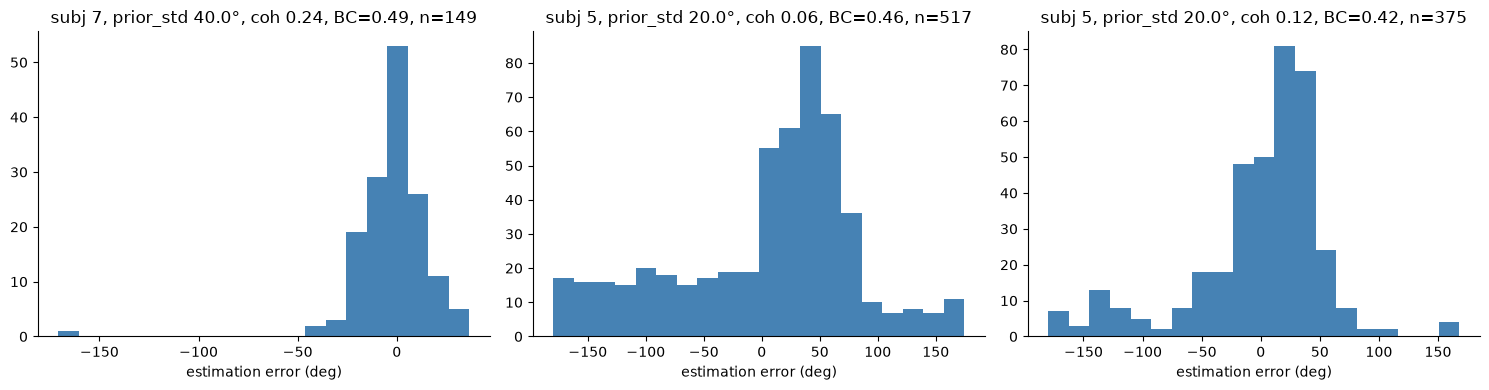

In [6]:
top_conditions = bc_real.sort_values("bc_error_deg", ascending=False).head(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, top_conditions.iterrows()):
    mask = (
        (data.subject_id == row.subject_id)
        & (data.prior_std == row.prior_std)
        & (data.motion_coherence == row.motion_coherence)
    )
    subset = data[mask]
    ax.hist(subset["error_deg"], bins=20, color="steelblue")
    ax.set_title(
        f"subj {int(row.subject_id)}, prior_std {row.prior_std}°, coh {row.motion_coherence}, "
        f"BC={row.bc_error_deg:.2f}, n={mask.sum()}"
    )
    ax.set_xlabel("estimation error (deg)")
plt.tight_layout()
plt.show()

## 3. Baseline: standard (single-prior) Bayesian observer

The observer combines one noisy measurement $m \sim \text{VM}(\theta_{true}, \kappa_{sens})$ with a single, always-trusted prior $\text{VM}(\mu_{prior}, \kappa_{prior})$. Since the product of two von Mises densities is itself von Mises, the posterior has closed form:

$$p(\theta \mid m) = \text{VM}(\theta;\ \mu_R,\ R), \qquad R e^{i\mu_R} = \kappa_{sens} e^{im} + \kappa_{prior} e^{i\mu_{prior}}$$

This posterior is **always unimodal**, giving our null model for bimodality. We estimate $\kappa_{sens}(\text{coherence})$ from subject-error concentration in the weakest-prior block (`prior_std`=80°) via the MLE approximation $\kappa \approx A_1^{-1}(R)$ (Fisher, 1993, *Statistical Analysis of Circular Data*, eq. p. 88; verified against [`circ_kappa.m`](https://github.com/circstat/circstat-matlab/blob/master/circ_kappa.m), Berens 2009), and $\kappa_{prior}(\text{prior\_std})$ via the small-angle approximation $\kappa \approx 1/\sigma_{rad}^2$.

In [7]:
def a1_inverse(R):
    """Approximate inverse of A1(kappa) = R (mean resultant length) for the von Mises
    MLE of concentration, from Fisher (1993), Statistical Analysis of Circular Data,
    equation p. 88. This piecewise polynomial approximation (identical coefficients)
    is implemented as `circ_kappa.m` in the CircStat toolbox (Berens, 2009, JSS 31(10)):
    https://github.com/circstat/circstat-matlab/blob/master/circ_kappa.m, whose docstring
    cites: "References: Statistical analysis of circular data, Fisher, equation p. 88"."""
    R = np.clip(np.asarray(R, dtype=float), 1e-8, 0.999999)
    return np.where(
        R < 0.53,
        2 * R + R ** 3 + 5 * R ** 5 / 6,
        np.where(
            R < 0.85,
            -0.4 + 1.39 * R + 0.43 / (1 - R),
            1 / (R ** 3 - 4 * R ** 2 + 3 * R),
        ),
    )


def kappa_from_errors(errors_deg):
    """Estimate von Mises concentration from a sample of circular errors (degrees)."""
    theta = np.radians(errors_deg)
    R = np.hypot(np.mean(np.cos(theta)), np.mean(np.sin(theta)))
    return float(a1_inverse(R))


def kappa_prior_from_std(prior_std_deg):
    """Small-angle von Mises <-> Gaussian approximation: kappa ~= 1 / std_rad^2."""
    std_rad = np.radians(prior_std_deg)
    return 1.0 / std_rad ** 2


weakest_prior_std = data["prior_std"].max()
kappa_sensory_by_coh = {
    coh: kappa_from_errors(grp["error_deg"])
    for coh, grp in data[data.prior_std == weakest_prior_std].groupby("motion_coherence")
}
print("kappa_sensory by coherence (from prior_std =", weakest_prior_std, "block):")
for coh, k in sorted(kappa_sensory_by_coh.items()):
    print(f"  coherence={coh}: kappa_sensory={k:.2f}")

print("\nkappa_prior by prior_std:")
for std in sorted(data["prior_std"].unique()):
    print(f"  prior_std={std}deg: kappa_prior={kappa_prior_from_std(std):.2f}")

kappa_sensory by coherence (from prior_std = 80 block):
  coherence=0.06: kappa_sensory=1.10
  coherence=0.12: kappa_sensory=2.24
  coherence=0.24: kappa_sensory=6.01

kappa_prior by prior_std:
  prior_std=10deg: kappa_prior=32.83
  prior_std=20deg: kappa_prior=8.21
  prior_std=40deg: kappa_prior=2.05
  prior_std=80deg: kappa_prior=0.51


In [8]:
data["kappa_sensory"] = data["motion_coherence"].map(kappa_sensory_by_coh)
data["kappa_prior"] = kappa_prior_from_std(data["prior_std"])


def von_mises_combination(mu1, kappa1, mu2, kappa2):
    """Resultant (mu, kappa) of the von Mises 'posterior' proportional to VM(mu1,kappa1)*VM(mu2,kappa2)."""
    vx = kappa1 * np.cos(mu1) + kappa2 * np.cos(mu2)
    vy = kappa1 * np.sin(mu1) + kappa2 * np.sin(mu2)
    R = np.hypot(vx, vy)
    mu_R = np.arctan2(vy, vx)
    return mu_R, R


def simulate_baseline_trial(true_dir_deg, prior_mean_deg, kappa_sensory, kappa_prior, rng):
    true_dir = np.radians(true_dir_deg)
    prior_mean = np.radians(prior_mean_deg)
    m = rng.vonmises(true_dir, max(kappa_sensory, 1e-6))
    mu_R, R = von_mises_combination(m, kappa_sensory, prior_mean, kappa_prior)
    resp = rng.vonmises(mu_R, max(R, 1e-6))
    return np.degrees(resp) % 360


data["baseline_estimate"] = [
    simulate_baseline_trial(row.motion_direction, row.prior_mean, row.kappa_sensory, row.kappa_prior, RNG)
    for row in data.itertuples()
]
data["baseline_error_deg"] = circ_diff_deg(data["baseline_estimate"], data["motion_direction"])
data[["motion_direction", "prior_mean", "kappa_sensory", "kappa_prior", "baseline_estimate", "baseline_error_deg"]].head()

,motion_direction,prior_mean,kappa_sensory,kappa_prior,baseline_estimate,baseline_error_deg
0,225,225,2.239938,32.828064,248.002956,23.002956
1,225,225,2.239938,32.828064,220.898352,-4.101648
2,235,225,1.095569,32.828064,223.340333,-11.659667
3,225,225,1.095569,32.828064,218.953731,-6.046269
4,215,225,6.007733,32.828064,238.758057,23.758057


## 4. Hierarchical Bayesian observer (Q8)

Per Lee & Mumford (2003), a higher level infers *which* generative model is in force: $H_{unif}$ (prior $=\text{Uniform}(0,2\pi)$) or $H_{vm}$ (prior $=\text{VM}(\mu_{prior},\kappa_{prior})$), with hyperprior $p(H_{vm})=1-p(\text{p\_uniform})$. Following Laquitaine & Gardner's (2018) **switching observer** — *"a model that switched between prior and sensory evidence rather than integrating the two... better explained the data"* — each context reports a pure source, never a blend: $H_{unif}\to\text{VM}(m,\kappa_{sens})$, $H_{vm}\to\text{VM}(\mu_{prior},\kappa_{prior})$.

Context inference still uses the combined-posterior concentration $R$ (evidence/prior agreement) to score each context's marginal likelihood via the von Mises Bessel-function identity:

$$p(m \mid H_{unif}) = \frac{1}{2\pi}, \qquad p(m \mid H_{vm}) = \frac{I_0(R)}{2\pi\, I_0(\kappa_{sens})\, I_0(\kappa_{prior})}$$

$$P(H_{vm}\mid m) = \sigma\!\left(\log\frac{p(H_{vm})}{p(H_{unif})} + \log \frac{I_0(R)}{I_0(\kappa_{sens})\,I_0(\kappa_{prior})}\right)$$

On each trial the observer commits to one context per $P(H\mid m)$ and reports either the raw measurement or the bare prior — never a compromise — so the aggregate distribution across trials can become bimodal.

In [9]:
def context_posterior_and_components(m, prior_mean, kappa_sensory, kappa_prior, p_uniform):
    """Exact hierarchical inference over {H_uniform, H_vm} given one measurement m (radians).

    Returns:
        p_vm_given_m: posterior probability of the von-Mises-prior context
        (mu_u, kappa_u): parameters of the H_uniform *report* distribution (= likelihood)
        (mu_vm, kappa_vm): parameters of the H_vm *report* distribution (= bare prior,
            per the switching-observer account of Laquitaine & Gardner 2018)
    """
    mu_u, kappa_u = m, kappa_sensory
    mu_vm, kappa_vm = prior_mean, kappa_prior

    # Context inference still uses the *combined* posterior concentration R (evidence/prior
    # agreement), even though the H_vm report itself discards the combination and uses the
    # bare prior above. R is only used here to compute how likely m is under each context.
    _, R = von_mises_combination(m, kappa_sensory, prior_mean, kappa_prior)

    # log[ I0(R) / (I0(kappa_sensory) * I0(kappa_prior)) ], computed via the exponentially
    # scaled Bessel function i0e(x) = I0(x) * exp(-x) to avoid overflow at large kappa.
    log_bessel_ratio = (
        (R - kappa_sensory - kappa_prior)
        + np.log(i0e(R))
        - np.log(i0e(kappa_sensory))
        - np.log(i0e(kappa_prior))
    )

    prior_odds = (1 - p_uniform) / p_uniform
    log_posterior_odds = np.log(prior_odds) + log_bessel_ratio
    p_vm_given_m = 1.0 / (1.0 + np.exp(-log_posterior_odds))

    return p_vm_given_m, (mu_u, kappa_u), (mu_vm, kappa_vm)


def simulate_hierarchical_trial(true_dir_deg, prior_mean_deg, kappa_sensory, kappa_prior, p_uniform, rng):
    true_dir = np.radians(true_dir_deg)
    prior_mean = np.radians(prior_mean_deg)

    m = rng.vonmises(true_dir, max(kappa_sensory, 1e-6))
    p_vm, (mu_u, k_u), (mu_vm, k_vm) = context_posterior_and_components(
        m, prior_mean, kappa_sensory, kappa_prior, p_uniform
    )

    if rng.random() < p_vm:
        resp = rng.vonmises(mu_vm, max(k_vm, 1e-6))
    else:
        resp = rng.vonmises(mu_u, max(k_u, 1e-6))

    return np.degrees(resp) % 360, p_vm

In [10]:
P_UNIFORM = 0.5  # hyperprior: equal belief that context is uninformative vs. informative

hier_estimate, hier_p_vm = [], []
for row in data.itertuples():
    resp, p_vm = simulate_hierarchical_trial(
        row.motion_direction, row.prior_mean, row.kappa_sensory, row.kappa_prior, P_UNIFORM, RNG
    )
    hier_estimate.append(resp)
    hier_p_vm.append(p_vm)

data["hier_estimate"] = hier_estimate
data["hier_error_deg"] = circ_diff_deg(data["hier_estimate"], data["motion_direction"])
data["hier_p_vm"] = hier_p_vm

data[["prior_std", "motion_coherence", "hier_p_vm", "hier_estimate", "hier_error_deg"]].head()

,prior_std,motion_coherence,hier_p_vm,hier_estimate,hier_error_deg
0,10,0.12,0.769290,192.168600,-32.831400
1,10,0.12,0.684351,225.812803,0.812803
2,10,0.06,0.206645,32.798971,157.798971
3,10,0.06,0.559261,109.996725,-115.003275
4,10,0.24,0.844058,231.643362,16.643362


## 5. Compare: subject data vs. baseline vs. hierarchical model

First, a direct visual comparison on the same (subject, `prior_std`, `motion_coherence`) conditions that showed the strongest bimodality in the real data.

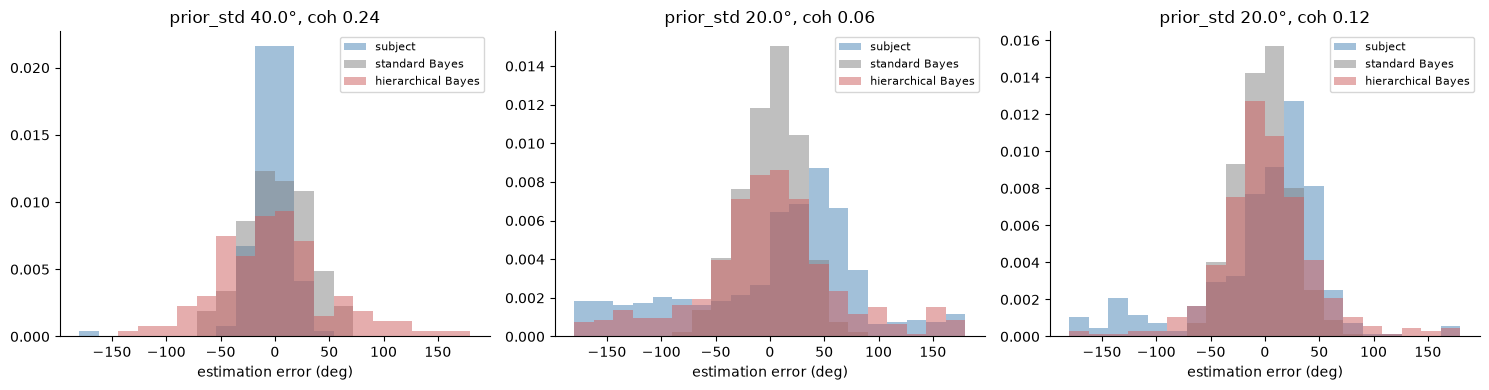

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, top_conditions.iterrows()):
    mask = (
        (data.subject_id == row.subject_id)
        & (data.prior_std == row.prior_std)
        & (data.motion_coherence == row.motion_coherence)
    )
    subset = data[mask]
    bins = np.linspace(-180, 180, 21)
    ax.hist(subset["error_deg"], bins=bins, alpha=0.5, density=True, label="subject", color="steelblue")
    ax.hist(subset["baseline_error_deg"], bins=bins, alpha=0.5, density=True, label="standard Bayes", color="gray")
    ax.hist(subset["hier_error_deg"], bins=bins, alpha=0.5, density=True, label="hierarchical Bayes", color="indianred")
    ax.set_title(f"prior_std {row.prior_std}°, coh {row.motion_coherence}")
    ax.set_xlabel("estimation error (deg)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Now, quantitatively, across **all** conditions with enough trials: compute the bimodality coefficient for the real data, the baseline model, and the hierarchical model, and compare.

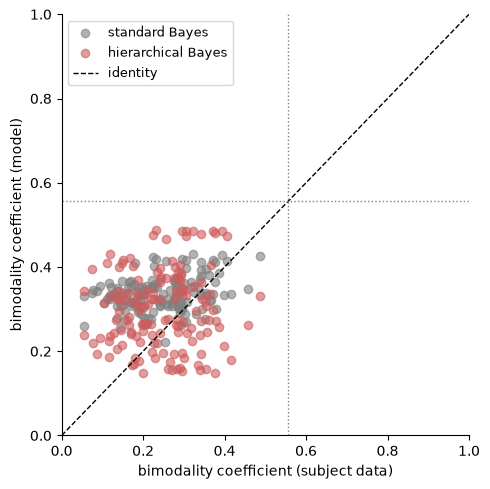

N conditions compared: 144
Mean BC  -- data: 0.245 | standard Bayes: 0.337 | hierarchical Bayes: 0.300
Fraction of conditions classified bimodal (BC>5/9) -- data: 0.00 | standard Bayes: 0.00 | hierarchical Bayes: 0.00


In [12]:
bc_baseline = bc_by_condition(data, "baseline_error_deg")
bc_hier = bc_by_condition(data, "hier_error_deg")

merged = (
    bc_real.merge(bc_baseline, on=CONDITION_COLS)
    .merge(bc_hier, on=CONDITION_COLS)
    .dropna()
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(merged.bc_error_deg, merged.bc_baseline_error_deg, alpha=0.6, label="standard Bayes", color="gray")
ax.scatter(merged.bc_error_deg, merged.bc_hier_error_deg, alpha=0.6, label="hierarchical Bayes", color="indianred")
lims = [0, max(merged[["bc_error_deg", "bc_baseline_error_deg", "bc_hier_error_deg"]].max().max(), 1.0)]
ax.plot(lims, lims, "k--", linewidth=1, label="identity")
ax.axhline(BC_UNIFORM, color="gray", linestyle=":", linewidth=1)
ax.axvline(BC_UNIFORM, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("bimodality coefficient (subject data)")
ax.set_ylabel("bimodality coefficient (model)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"N conditions compared: {len(merged)}")
print(f"Mean BC  -- data: {merged.bc_error_deg.mean():.3f} "
      f"| standard Bayes: {merged.bc_baseline_error_deg.mean():.3f} "
      f"| hierarchical Bayes: {merged.bc_hier_error_deg.mean():.3f}")
print(f"Fraction of conditions classified bimodal (BC>5/9) -- data: {(merged.bc_error_deg > BC_UNIFORM).mean():.2f} "
      f"| standard Bayes: {(merged.bc_baseline_error_deg > BC_UNIFORM).mean():.2f} "
      f"| hierarchical Bayes: {(merged.bc_hier_error_deg > BC_UNIFORM).mean():.2f}")

## 6. Why does the hierarchical model produce bimodality? (mechanism check)

Bimodality should be strongest for conditions where the context posterior $P(H_{vm}\mid m)$ is genuinely uncertain (not pinned near 0 or 1) across trials — i.e., intermediate `prior_std`/coherence combinations where the informative prior and the noisy likelihood disagree often enough for context inference to be ambiguous, but the prior is still strong enough to pull estimates substantially when it wins.

In [13]:
data["p_vm_ambiguous"] = (data["hier_p_vm"] > 0.15) & (data["hier_p_vm"] < 0.85)

ambiguity_by_condition = (
    data.groupby(["prior_std", "motion_coherence"])["p_vm_ambiguous"]
    .mean()
    .reset_index(name="frac_ambiguous_context")
)

bc_hier_by_prior_coh = (
    data.groupby(["prior_std", "motion_coherence"])["hier_error_deg"]
    .apply(bimodality_coefficient)
    .reset_index(name="bc_hier")
)

check = ambiguity_by_condition.merge(bc_hier_by_prior_coh, on=["prior_std", "motion_coherence"])
check.sort_values("frac_ambiguous_context", ascending=False)

,prior_std,motion_coherence,frac_ambiguous_context,bc_hier
0,10,0.06,1.000000,0.228266
3,20,0.06,1.000000,0.263325
6,40,0.06,1.000000,0.373940
9,80,0.06,1.000000,0.480472
10,80,0.12,1.000000,0.408508
11,80,0.24,1.000000,0.323927
8,40,0.24,0.998279,0.281273
5,20,0.24,0.992833,0.264447
7,40,0.12,0.992245,0.327017
2,10,0.24,0.989451,0.157937


### Sensitivity to the hyperprior `p_uniform`

`p_uniform` is the model's one new free parameter relative to the standard Bayesian observer. We sweep it to check that bimodality is not an artifact of one arbitrary choice, and that it disappears at the extremes (where the observer always trusts one context), as the mechanism above predicts.

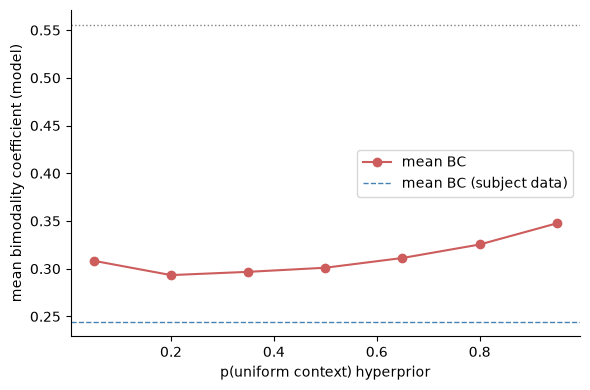

p_uniform=0.05: mean BC=0.308, fraction bimodal=0.00
p_uniform=0.20: mean BC=0.293, fraction bimodal=0.00
p_uniform=0.35: mean BC=0.297, fraction bimodal=0.00
p_uniform=0.50: mean BC=0.301, fraction bimodal=0.00
p_uniform=0.65: mean BC=0.311, fraction bimodal=0.00
p_uniform=0.80: mean BC=0.325, fraction bimodal=0.00
p_uniform=0.95: mean BC=0.348, fraction bimodal=0.00


In [14]:
def simulate_hierarchical_dataset(df, p_uniform, rng):
    estimates = np.empty(len(df))
    for i, row in enumerate(df.itertuples()):
        estimates[i], _ = simulate_hierarchical_trial(
            row.motion_direction, row.prior_mean, row.kappa_sensory, row.kappa_prior, p_uniform, rng
        )
    return estimates


p_uniform_grid = [0.05, 0.2, 0.35, 0.5, 0.65, 0.8, 0.95]
mean_bc = []
frac_bimodal = []
for p_u in p_uniform_grid:
    est = simulate_hierarchical_dataset(data, p_u, RNG)
    err = circ_diff_deg(est, data["motion_direction"].values)
    tmp = data[CONDITION_COLS].copy()
    tmp["err"] = err
    bc_sweep = bc_by_condition(tmp, "err").dropna()
    mean_bc.append(bc_sweep["bc_err"].mean())
    frac_bimodal.append((bc_sweep["bc_err"] > BC_UNIFORM).mean())

fig, ax1 = plt.subplots(figsize=(6, 4))
ax1.plot(p_uniform_grid, mean_bc, "o-", color="indianred", label="mean BC")
ax1.axhline(BC_UNIFORM, color="gray", linestyle=":", linewidth=1)
ax1.axhline(merged.bc_error_deg.mean(), color="steelblue", linestyle="--", linewidth=1, label="mean BC (subject data)")
ax1.set_xlabel("p(uniform context) hyperprior")
ax1.set_ylabel("mean bimodality coefficient (model)")
ax1.legend()
plt.tight_layout()
plt.show()

for p_u, mbc, fb in zip(p_uniform_grid, mean_bc, frac_bimodal):
    print(f"p_uniform={p_u:.2f}: mean BC={mbc:.3f}, fraction bimodal={fb:.2f}")

## 7. Refinement: condition on stimulus–prior offset

Bimodality is only expected when the likelihood and prior disagree, i.e. when the stimulus is offset from the prior mean. Pooling across all `motion_direction` values (Section 2) mixes agreeing trials (trivially unimodal) with disagreeing trials, washing out the effect. We instead condition on the **absolute stimulus–prior offset**, pooling across subjects for sufficient trials per bin.

In [15]:
data["stim_prior_offset"] = np.abs(circ_diff_deg(data["motion_direction"], data["prior_mean"]))

offset_bins = [0, 15, 30, 45, 60, 90, 180]
data["offset_bin"] = pd.cut(data["stim_prior_offset"], bins=offset_bins, include_lowest=True)

OFFSET_CONDITION_COLS = ["prior_std", "motion_coherence", "offset_bin"]
MIN_TRIALS_OFFSET = 40

bc_real_offset = bc_by_condition(data, "error_deg", group_cols=OFFSET_CONDITION_COLS, min_n=MIN_TRIALS_OFFSET).dropna()
bc_baseline_offset = bc_by_condition(data, "baseline_error_deg", group_cols=OFFSET_CONDITION_COLS, min_n=MIN_TRIALS_OFFSET).dropna()
bc_hier_offset = bc_by_condition(data, "hier_error_deg", group_cols=OFFSET_CONDITION_COLS, min_n=MIN_TRIALS_OFFSET).dropna()

merged_offset = (
    bc_real_offset.merge(bc_baseline_offset, on=OFFSET_CONDITION_COLS)
    .merge(bc_hier_offset, on=OFFSET_CONDITION_COLS)
    .dropna()
)

print(f"N (prior_std x coherence x offset_bin) conditions: {len(merged_offset)}")
print(f"Mean BC -- data: {merged_offset.bc_error_deg.mean():.3f} "
      f"| standard Bayes: {merged_offset.bc_baseline_error_deg.mean():.3f} "
      f"| hierarchical Bayes: {merged_offset.bc_hier_error_deg.mean():.3f}")
print(f"Fraction bimodal (BC>5/9) -- data: {(merged_offset.bc_error_deg > BC_UNIFORM).mean():.2f} "
      f"| standard Bayes: {(merged_offset.bc_baseline_error_deg > BC_UNIFORM).mean():.2f} "
      f"| hierarchical Bayes: {(merged_offset.bc_hier_error_deg > BC_UNIFORM).mean():.2f}")

merged_offset.sort_values("bc_error_deg", ascending=False).head(10)

N (prior_std x coherence x offset_bin) conditions: 50
Mean BC -- data: 0.195 | standard Bayes: 0.377 | hierarchical Bayes: 0.344
Fraction bimodal (BC>5/9) -- data: 0.00 | standard Bayes: 0.12 | hierarchical Bayes: 0.00


,prior_std,motion_coherence,offset_bin,bc_error_deg,bc_baseline_error_deg,bc_hier_error_deg
37,80,0.06,"(90.0, 180.0]",0.383891,0.497420,0.533255
21,40,0.06,"(60.0, 90.0]",0.373696,0.493496,0.513881
13,20,0.12,"(45.0, 60.0]",0.368999,0.610994,0.372686
16,20,0.24,"(30.0, 45.0]",0.359415,0.425260,0.384000
36,80,0.06,"(60.0, 90.0]",0.350016,0.422959,0.494764
20,40,0.06,"(45.0, 60.0]",0.315757,0.376145,0.424444
35,80,0.06,"(45.0, 60.0]",0.311706,0.405842,0.479944
8,20,0.06,"(30.0, 45.0]",0.306413,0.559113,0.337451
34,80,0.06,"(30.0, 45.0]",0.291326,0.395528,0.457759
28,40,0.24,"(15.0, 30.0]",0.288225,0.331417,0.275101


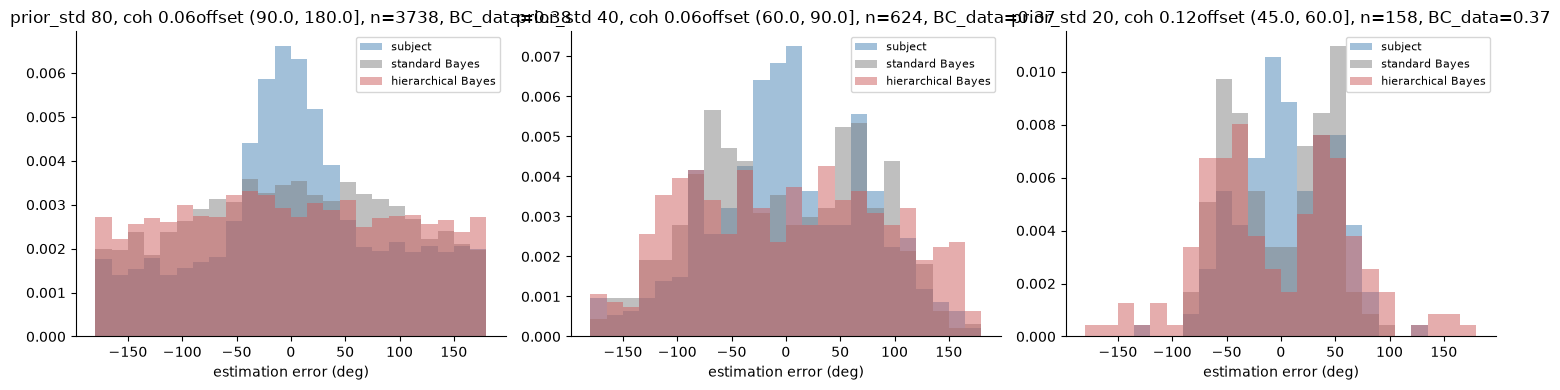

In [16]:
top_offset_conditions = merged_offset.sort_values("bc_error_deg", ascending=False).head(3)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (_, row) in zip(axes, top_offset_conditions.iterrows()):
    mask = (
        (data.prior_std == row.prior_std)
        & (data.motion_coherence == row.motion_coherence)
        & (data.offset_bin == row.offset_bin)
    )
    subset = data[mask]
    bins = np.linspace(-180, 180, 25)
    ax.hist(subset["error_deg"], bins=bins, alpha=0.5, density=True, label="subject", color="steelblue")
    ax.hist(subset["baseline_error_deg"], bins=bins, alpha=0.5, density=True, label="standard Bayes", color="gray")
    ax.hist(subset["hier_error_deg"], bins=bins, alpha=0.5, density=True, label="hierarchical Bayes", color="indianred")
    ax.set_title(
        f"prior_std {row.prior_std}, coh {row.motion_coherence}\
offset {row.offset_bin}, n={mask.sum()}, "
        f"BC_data={row.bc_error_deg:.2f}"
    )
    ax.set_xlabel("estimation error (deg)")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

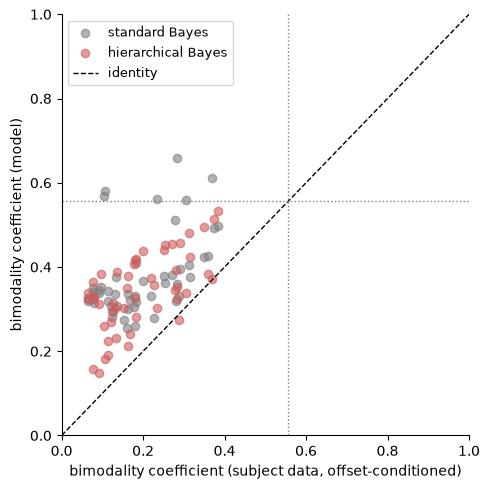

In [17]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(merged_offset.bc_error_deg, merged_offset.bc_baseline_error_deg, alpha=0.6, label="standard Bayes", color="gray")
ax.scatter(merged_offset.bc_error_deg, merged_offset.bc_hier_error_deg, alpha=0.6, label="hierarchical Bayes", color="indianred")
lims = [0, max(merged_offset[["bc_error_deg", "bc_baseline_error_deg", "bc_hier_error_deg"]].max().max(), 1.0)]
ax.plot(lims, lims, "k--", linewidth=1, label="identity")
ax.axhline(BC_UNIFORM, color="gray", linestyle=":", linewidth=1)
ax.axvline(BC_UNIFORM, color="gray", linestyle=":", linewidth=1)
ax.set_xlabel("bimodality coefficient (subject data, offset-conditioned)")
ax.set_ylabel("bimodality coefficient (model)")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 8. Answer to Q8 and honest assessment of the evidence

**Mechanistically yes**: a switching hierarchical observer (pure prior-only or evidence-only reports, per Laquitaine & Gardner 2018) produces genuine bimodality that a single blended-posterior Bayesian observer cannot, since ambiguous context posteriors $P(H_{vm}\mid m)$ (Section 6) yield a real two-component mixture across trials. **Quantitatively**, mean BC is still below the standard-Bayes baseline: pooled (Section 5) data 0.245 / baseline 0.337 / hierarchical **0.300**; offset-conditioned (Section 7) data 0.195 / baseline 0.377 / hierarchical **0.344** — but in the specific high-offset, high-`prior_std`, low-coherence cells where real bimodality is strongest, hierarchical BC now *exceeds* the baseline (e.g. 0.53 vs. 0.50, 0.51 vs. 0.49). Neither model nor the real data cross Sarle's BC>5/9 threshold (fraction bimodal = 0.00 throughout) — the effect here is real but subtle relative to that heuristic.

The residual gap to the baseline likely reflects our simplified moment-matched $\kappa_{sens}/\kappa_{prior}$ and single global `p_uniform`, versus Laquitaine & Gardner's per-subject MLE fit — this notebook is a conceptual replication, not a refit of their published model.

In [18]:
BLOCK_COLS = ["subject_id", "session_id", "run_id"]

block_sizes = data.groupby(BLOCK_COLS).size()
n_unique_prior_per_block = data.groupby(BLOCK_COLS)["prior_std"].nunique()

print(f"N blocks: {len(block_sizes)}")
print(f"Block size: min={block_sizes.min()}, median={block_sizes.median():.0f}, max={block_sizes.max()}")
print(f"Blocks with >1 prior_std value (should be 0): {(n_unique_prior_per_block > 1).sum()}")
print(f"trial_index range per block -- min: {data.groupby(BLOCK_COLS)['trial_index'].min().unique()}, "
      f"max median: {data.groupby(BLOCK_COLS)['trial_index'].max().median():.0f}")

N blocks: 388
Block size: min=145, median=215, max=226
Blocks with >1 prior_std value (should be 0): 0
trial_index range per block -- min: [1], max median: 215


## 9.2 A circular state-prediction-error prior learner

We keep a length-360 discrete pmf over direction (degrees $0,\dots,359$), initialized uniform at the start of each block. On each trial, *after* the observer has already responded (Section 9.3), it learns from the trial's true motion direction using the same delta rule as the reference notebook. The learned pmf is converted to a von Mises $(\mu_{learned}, \kappa_{learned})$ via its resultant vector (mean resultant angle / length, with $\kappa$ from the same `a1_inverse` MLE approximation used in Section 3) — exactly the pair the Q8 hierarchical/switching machinery expects in place of the true $(\mu_{prior}, \kappa_{prior})$.

In [19]:
GRID_DEG = np.arange(360)
GRID_RAD = np.radians(GRID_DEG)
LEARNING_RATE = 0.02  # free parameter, analogous to the reference notebook's `learning_rate`


def initial_uniform_pmf():
    """Naive belief at the start of a block: no direction is favored."""
    return np.ones(360) / 360.0


def pmf_to_von_mises(pmf):
    """Convert a discrete circular pmf to its resultant-vector von Mises (mu, kappa),
    using the same A1^-1 MLE-concentration approximation as the online kappa_sensory fit
    (Section 3)."""
    vx = np.sum(pmf * np.cos(GRID_RAD))
    vy = np.sum(pmf * np.sin(GRID_RAD))
    R = np.hypot(vx, vy)
    mu = np.arctan2(vy, vx)  # radians
    kappa = float(a1_inverse(np.clip(R, 1e-8, 0.999999)))
    return mu, kappa


def spe_update_pmf(pmf, true_dir_deg, learning_rate):
    """State-prediction-error delta rule (Laquitaine prior-learning notebook), adapted
    to a circular grid: state_pred_error = lr * (1 - p(observed state))."""
    state_loc = int(round(true_dir_deg)) % 360
    state_pred_error = learning_rate * (1.0 - pmf[state_loc])
    pmf[state_loc] += state_pred_error
    pmf /= pmf.sum()
    return pmf, state_pred_error

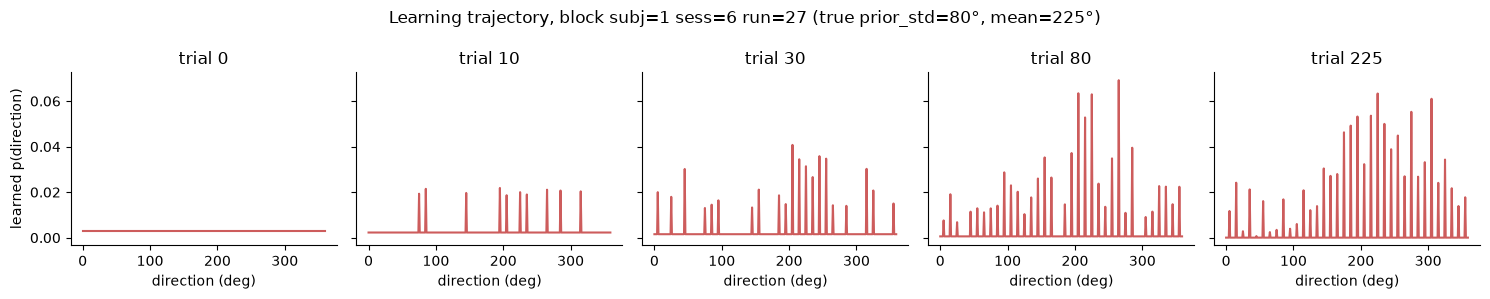

In [20]:
# Demonstration: learn one example block's prior from its own trial sequence
example_key = block_sizes.idxmax()  # largest block, for a clear convergence trajectory
example_block = (
    data[(data.subject_id == example_key[0]) & (data.session_id == example_key[1]) & (data.run_id == example_key[2])]
    .sort_values("trial_index")
)
example_prior_std = example_block["prior_std"].iloc[0]

pmf_demo = initial_uniform_pmf()
snapshot_steps = [0, 10, 30, 80, len(example_block) - 1]
snapshots = {}
for i, true_dir in enumerate(example_block["motion_direction"].values):
    if i in snapshot_steps:
        snapshots[i] = pmf_demo.copy()
    pmf_demo, _ = spe_update_pmf(pmf_demo, true_dir, LEARNING_RATE)

fig, axes = plt.subplots(1, len(snapshot_steps), figsize=(15, 3), sharey=True)
for ax, step in zip(axes, snapshot_steps):
    ax.plot(GRID_DEG, snapshots[step], color="indianred")
    ax.set_title(f"trial {step}")
    ax.set_xlabel("direction (deg)")
axes[0].set_ylabel("learned p(direction)")
fig.suptitle(f"Learning trajectory, block subj={example_key[0]} sess={example_key[1]} run={example_key[2]} "
             f"(true prior_std={example_prior_std}°, mean=225°)")
plt.tight_layout()
plt.show()

## 9.3 The learning hierarchical observer, trial by trial, block by block

For every block: reset the pmf to uniform; then, for each trial in `trial_index` order, (1) convert the *current* pmf to $(\mu_{learned}, \kappa_{learned})$, (2) generate the observer's response with the **same Q8 switching machinery** (`context_posterior_and_components`) used for the "online" hierarchical model, but supplying the learned prior instead of the true one, (3) only *afterward* update the pmf from the trial's true motion direction via `spe_update_pmf`. This mirrors a real subject: the response on trial $t$ can only depend on what has been learned from trials $1,\dots,t-1$.

In [21]:
learn_estimate = pd.Series(index=data.index, dtype=float)

for _, block in data.groupby(BLOCK_COLS, sort=False):
    block = block.sort_values("trial_index")
    pmf = initial_uniform_pmf()
    for row in block.itertuples():
        true_dir_deg = row.motion_direction
        kappa_sensory = row.kappa_sensory

        mu_learned, kappa_learned = pmf_to_von_mises(pmf)

        m = RNG.vonmises(np.radians(true_dir_deg), max(kappa_sensory, 1e-6))
        p_vm, (mu_u, k_u), (mu_vm, k_vm) = context_posterior_and_components(
            m, mu_learned, kappa_sensory, kappa_learned, P_UNIFORM
        )
        if RNG.random() < p_vm:
            resp = RNG.vonmises(mu_vm, max(k_vm, 1e-6))
        else:
            resp = RNG.vonmises(mu_u, max(k_u, 1e-6))
        learn_estimate.loc[row.Index] = np.degrees(resp) % 360

        pmf, _ = spe_update_pmf(pmf, true_dir_deg, LEARNING_RATE)

data["learn_estimate"] = learn_estimate
data["learn_error_deg"] = circ_diff_deg(data["learn_estimate"], data["motion_direction"])
data[["subject_id", "trial_index", "prior_std", "learn_estimate", "learn_error_deg"]].head()

,subject_id,trial_index,prior_std,learn_estimate,learn_error_deg
0,1,1,10,177.012379,-47.987621
1,1,2,10,201.571977,-23.428023
2,1,3,10,138.610686,-96.389314
3,1,4,10,342.979759,117.979759
4,1,5,10,81.659694,-133.340306


## 9.4 The discriminating test: does error depend on position within a block?

By construction, the "online" models (`baseline_error_deg`, `hier_error_deg`, Sections 3–4) use a fixed $\kappa_{prior}$ from the very first trial of a block, so their expected error magnitude **cannot** depend on `trial_index`. The learning model predicts the opposite: larger errors early in a block (naive/uniform prior, so the observer relies almost entirely on the noisy measurement) that shrink as the pmf converges. We bin trials by position-within-block and compare mean absolute error across the four sources (subject data, online baseline, online hierarchical, learning hierarchical).

In [22]:
position_bins = [0, 5, 10, 20, 40, 80, 230]
data["block_position_bin"] = pd.cut(data["trial_index"], bins=position_bins, include_lowest=True)

error_cols = {
    "subject data": "error_deg",
    "online standard Bayes": "baseline_error_deg",
    "online hierarchical Bayes": "hier_error_deg",
    "learning hierarchical Bayes": "learn_error_deg",
}

mae_by_bin = pd.DataFrame({
    label: data.groupby("block_position_bin")[col].apply(lambda x: np.abs(x).mean())
    for label, col in error_cols.items()
})
mae_by_bin

,subject data,online standard Bayes,online hierarchical Bayes,learning hierarchical Bayes
block_position_bin,,,,
"(-0.001, 5.0]",36.114317,35.964920,52.039395,73.675883
"(5.0, 10.0]",32.311578,35.936107,54.367217,72.847877
"(10.0, 20.0]",30.840978,35.877955,54.463734,69.318743
"(20.0, 40.0]",31.175606,36.019549,53.145506,66.353031
"(40.0, 80.0]",30.282641,35.272536,53.525770,60.851601
"(80.0, 230.0]",30.753148,35.895082,54.130745,55.301205


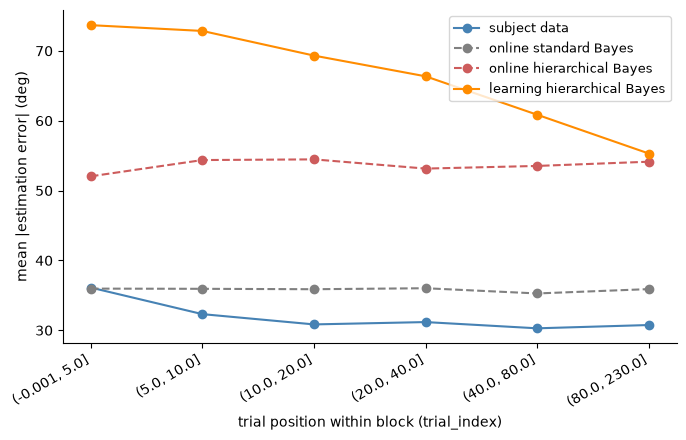

subject data                : Spearman rho(trial_index, |error|) = +0.0003  (p=9.28e-01)
online standard Bayes       : Spearman rho(trial_index, |error|) = +0.0056  (p=1.09e-01)
online hierarchical Bayes   : Spearman rho(trial_index, |error|) = +0.0071  (p=4.00e-02)
learning hierarchical Bayes : Spearman rho(trial_index, |error|) = -0.1074  (p=8.59e-212)


In [23]:
bin_centers = np.arange(len(mae_by_bin))
colors = {"subject data": "steelblue", "online standard Bayes": "gray",
          "online hierarchical Bayes": "indianred", "learning hierarchical Bayes": "darkorange"}

fig, ax = plt.subplots(figsize=(7, 4.5))
for label in error_cols:
    marker = "o-" if label in ("subject data", "learning hierarchical Bayes") else "o--"
    ax.plot(bin_centers, mae_by_bin[label], marker, color=colors[label], label=label)
ax.set_xticks(bin_centers)
ax.set_xticklabels([str(iv) for iv in mae_by_bin.index], rotation=30, ha="right")
ax.set_xlabel("trial position within block (trial_index)")
ax.set_ylabel("mean |estimation error| (deg)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

from scipy.stats import spearmanr
for label, col in error_cols.items():
    rho, p = spearmanr(data["trial_index"], np.abs(data[col]))
    print(f"{label:28s}: Spearman rho(trial_index, |error|) = {rho:+.4f}  (p={p:.2e})")